In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
data = pd.read_pickle("../data/processed/epias_cleaned.pkl")

data.head()

,Tarih,Saat,PTF,SMF,Pozitif Dengesizlik Fiyatı (TL/MWh),Negatif Dengesizlik Fiyatı (TL/MWh),SMF Yön,month,day,season
2024-01-01 00:00:00,01.01.2024,00:00,1299.98,560.00,543.20,1338.98,Enerji Fazlası,1,Monday,winter
2024-01-01 01:00:00,01.01.2024,01:00,1299.98,1299.98,1260.98,1338.98,Enerji Fazlası,1,Monday,winter
2024-01-01 02:00:00,01.01.2024,02:00,1248.54,1248.54,1211.08,1286.00,Enerji Fazlası,1,Monday,winter
2024-01-01 03:00:00,01.01.2024,03:00,1299.98,1250.00,1212.50,1338.98,Enerji Fazlası,1,Monday,winter
2024-01-01 04:00:00,01.01.2024,04:00,1200.00,1150.00,1115.50,1236.00,Enerji Fazlası,1,Monday,winter


C:\Users\90546\AppData\Local\Temp\ipykernel_22732\299663368.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Saat', y='PTF', data=data, palette="viridis")


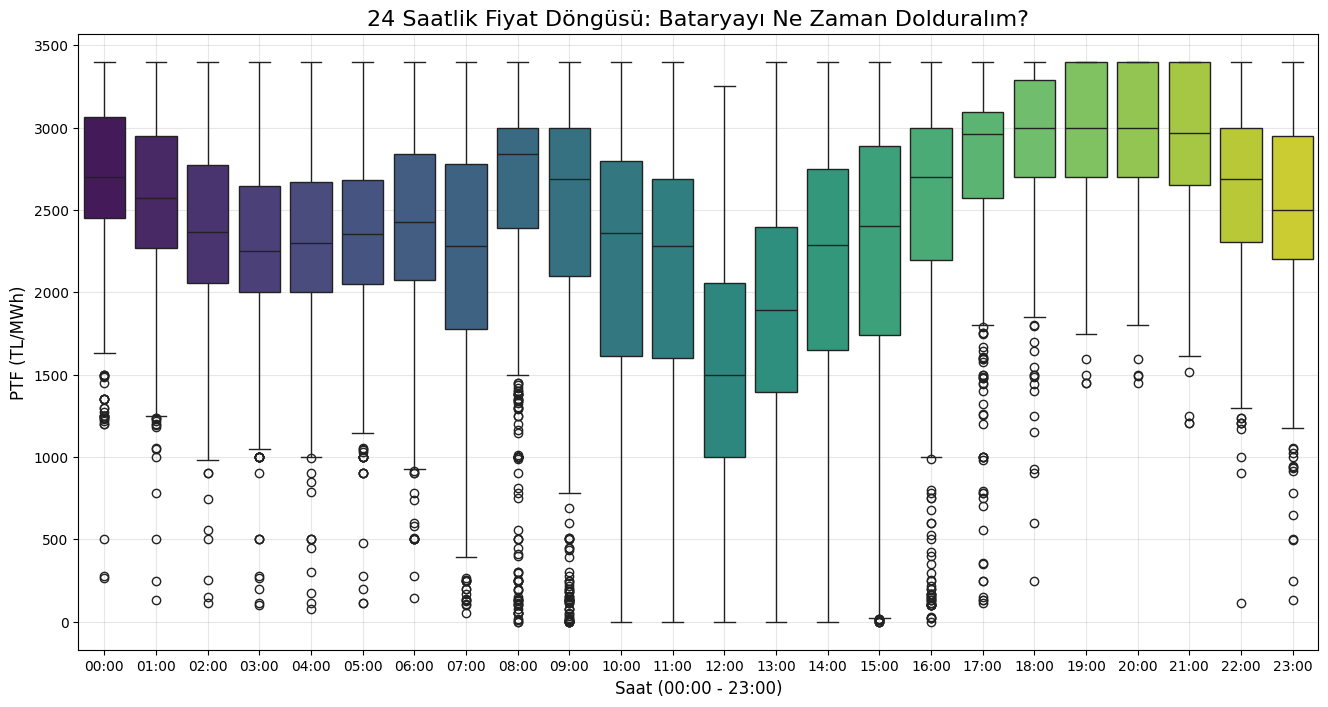

In [4]:
plt.figure(figsize=(16, 8))
sns.boxplot(x='Saat', y='PTF', data=data, palette="viridis")

plt.title('24 Saatlik Fiyat Döngüsü: Bataryayı Ne Zaman Dolduralım?', fontsize=16)
plt.xlabel('Saat (00:00 - 23:00)', fontsize=12)
plt.ylabel('PTF (TL/MWh)', fontsize=12)
plt.grid(True, alpha=0.3)
plt.show()

burada aykırı değerler var. bunların sebebini araştırmamız lazım. hava durumu, haftasonu, resmi tatiller vs analize dahil edilmeli.Mesela saat 08:00'de çok aykırı değer olmuş? Outlier Analizi :

In [5]:
def find_hourly_lower_bounder(data, target_col='PTF', q1=0.25, q3=0.75, plot=False):
    outliers_list = []
    unique_hours = sorted(data['Saat'].unique())
    # --- 1. HESAPLAMA KISMI ---
    for hour in unique_hours:
        hour_data = data[data['Saat'] == hour]
        
        if hour_data.empty: continue
        
        Q1 = hour_data[target_col].quantile(q1)
        Q3 = hour_data[target_col].quantile(q3)
        IQR = Q3 - Q1
        
        lower_bound = Q1 - 1.5 * IQR
        
        # Sadece alt sınırın (lower_bound) altındakileri alıyoruz
        outliers = hour_data[hour_data[target_col] < lower_bound]
        
        if not outliers.empty:
            outliers_list.append(outliers)

    # --- 2. VERİYİ BİRLEŞTİRME ---
    if outliers_list:
        result_df = pd.concat(outliers_list)
    else:
        print("✅ Hiç aykırı değer bulunamadı.")
        return pd.DataFrame()
    
    # --- 3. GÖRSELLEŞTİRME KISMI ---
    if plot:
        print(f"Toplam {len(result_df)} adet aykırı değer bulundu. Grafikler: \n")
        
        # Grafik 1: Mevsim Dağılımı
        plt.figure(figsize=(16, 5))
        sns.countplot(data=result_df, x="Saat", hue="season", palette="Set1")
        plt.title("Hangi Saatteki Düşüş Hangi Mevsimde Oluyor?", fontsize=14)
        plt.grid(axis='y', alpha=0.3)
        plt.legend(loc='upper right')
        plt.show()

        # Grafik 2: Gün Dağılımı
        plt.figure(figsize=(16, 5))
        days_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
        sns.countplot(data=result_df, x="Saat", hue="day", hue_order=days_order, palette="viridis")
        plt.title("Hangi Saatteki Düşüş Hangi Güne Denk Geliyor?", fontsize=14)
        plt.grid(axis='y', alpha=0.3)
        plt.legend(loc='upper right')
        plt.show()

    return result_df

Toplam 412 adet aykırı değer bulundu. Grafikler: 



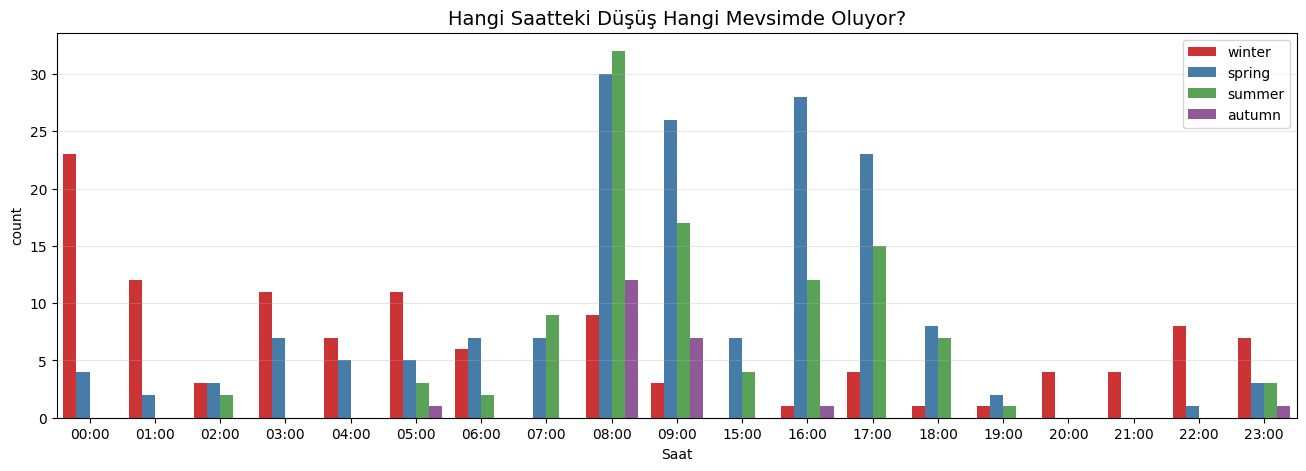

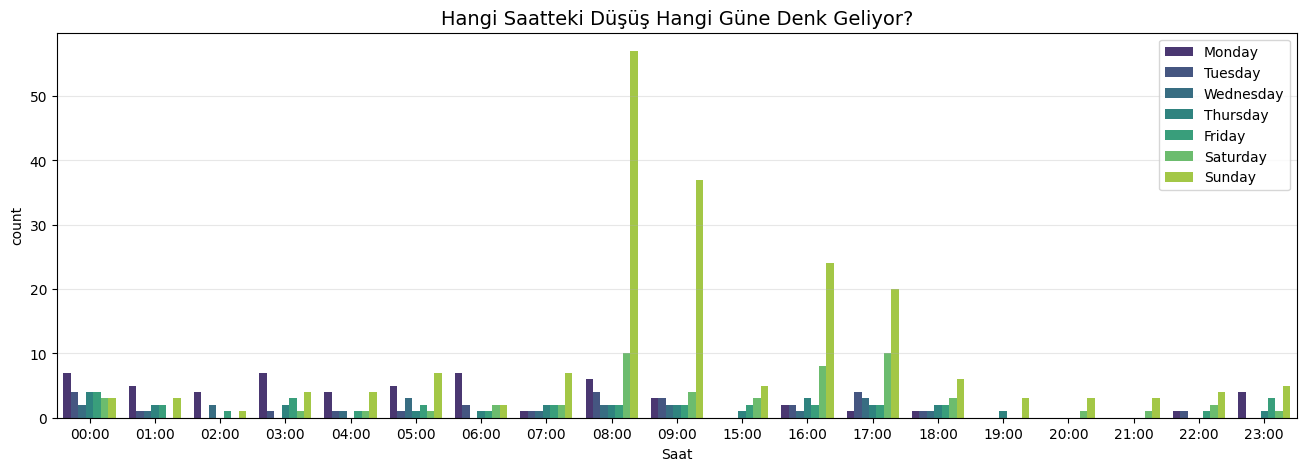

In [6]:
lower_bounder_data = find_hourly_lower_bounder(data,plot=True)

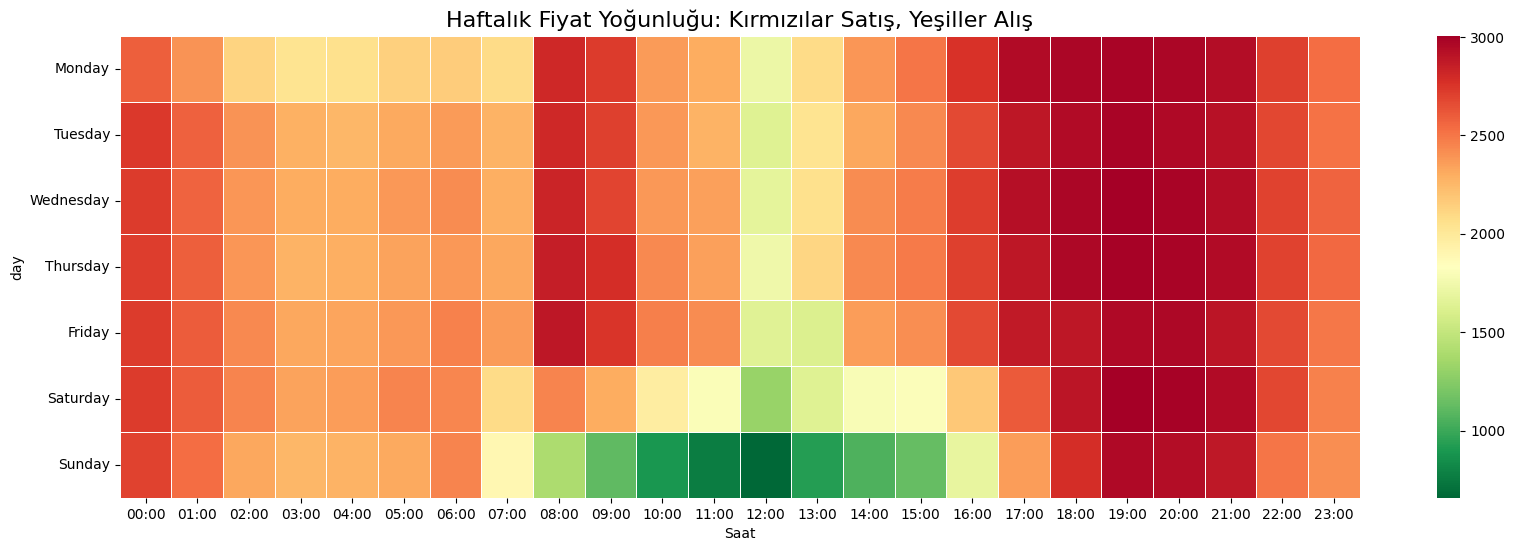

In [7]:
# Veriyi 'Gün x Saat' matrisine çevir
pivot_table = data.pivot_table(values='PTF', index='day', columns='Saat', aggfunc='mean')

# Günleri doğru sıraya diz (İngilizce ise)
order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
pivot_table = pivot_table.reindex(order)

plt.figure(figsize=(20, 6))
# Kırmızı=Pahalı, Yeşil=Ucuz
sns.heatmap(pivot_table, cmap='RdYlGn_r', annot=False, linewidths=.5)

plt.title('Haftalık Fiyat Yoğunluğu: Kırmızılar Satış, Yeşiller Alış', fontsize=16)
plt.show()

Grafik çıktılarına göre modelden beklentilerimiz :
1-Kış aylarında gece elektrik talebi diplerdeyken rüzgardan dolayı arz oldukca fazla : O zaman kış geceleri batarya dolumu olmalı.
2-Gün grafiğine bakarsak düşüşlerin temel sebebi pazar gününe bagımlı. onun dısında anlamlı bir sonuc yok.
3-yaz bahar aylarında gündüz 08-18 saat arasında fiyatların düşüşüne rastlanmış. Ges etkisi sonucu arz > talep dolasyısıyla fiyat düşüşü



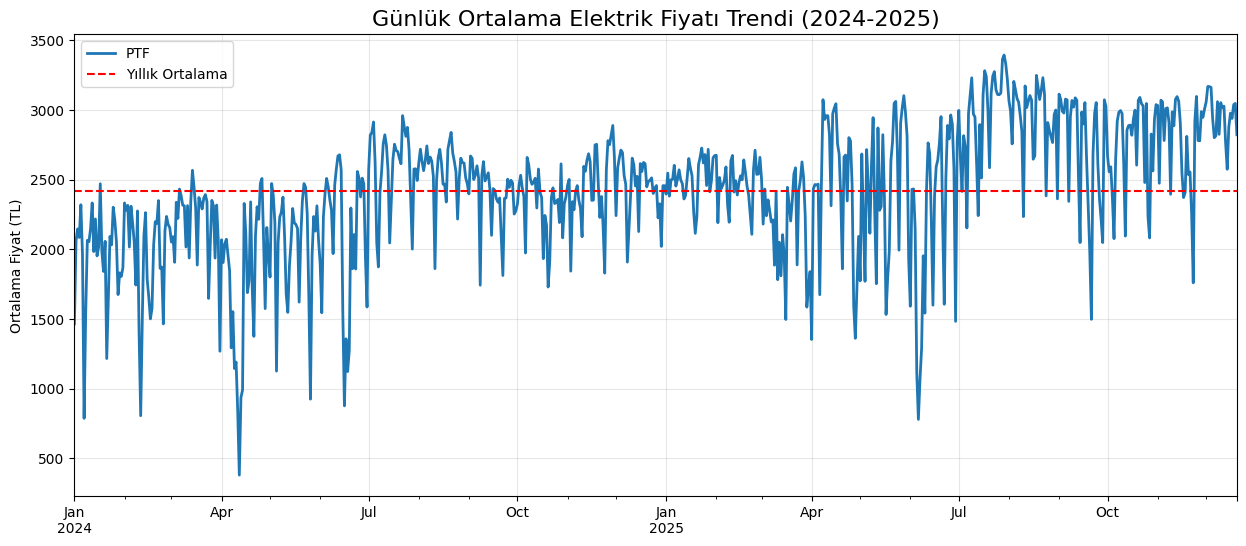

In [8]:
daily_avg = data['PTF'].resample('D').mean()
plt.figure(figsize=(15, 6))
daily_avg.plot(color='#1f77b4', linewidth=2)

# Ortalamayı da çizelim (Referans olsun)
plt.axhline(daily_avg.mean(), color='red', linestyle='--', label='Yıllık Ortalama')

plt.title('Günlük Ortalama Elektrik Fiyatı Trendi (2024-2025)', fontsize=16)
plt.ylabel('Ortalama Fiyat (TL)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

grafiğin başında(2024) elektrik fiyatları ortalamanın altında iken grafiğin sonunda(2025) ortalama üzerinde olması enerji maliyetlerinin yükseldiğini gösterir.
nisan çöküşü : bahar yağmurları , hava ılıman oldugu için tüketim düşük. bayram tatilleri sebebiyle düşük sanayi tüketimi.
Fiyatların volatil olması bataryacılar için olumlu, üreticiler için olumsuz

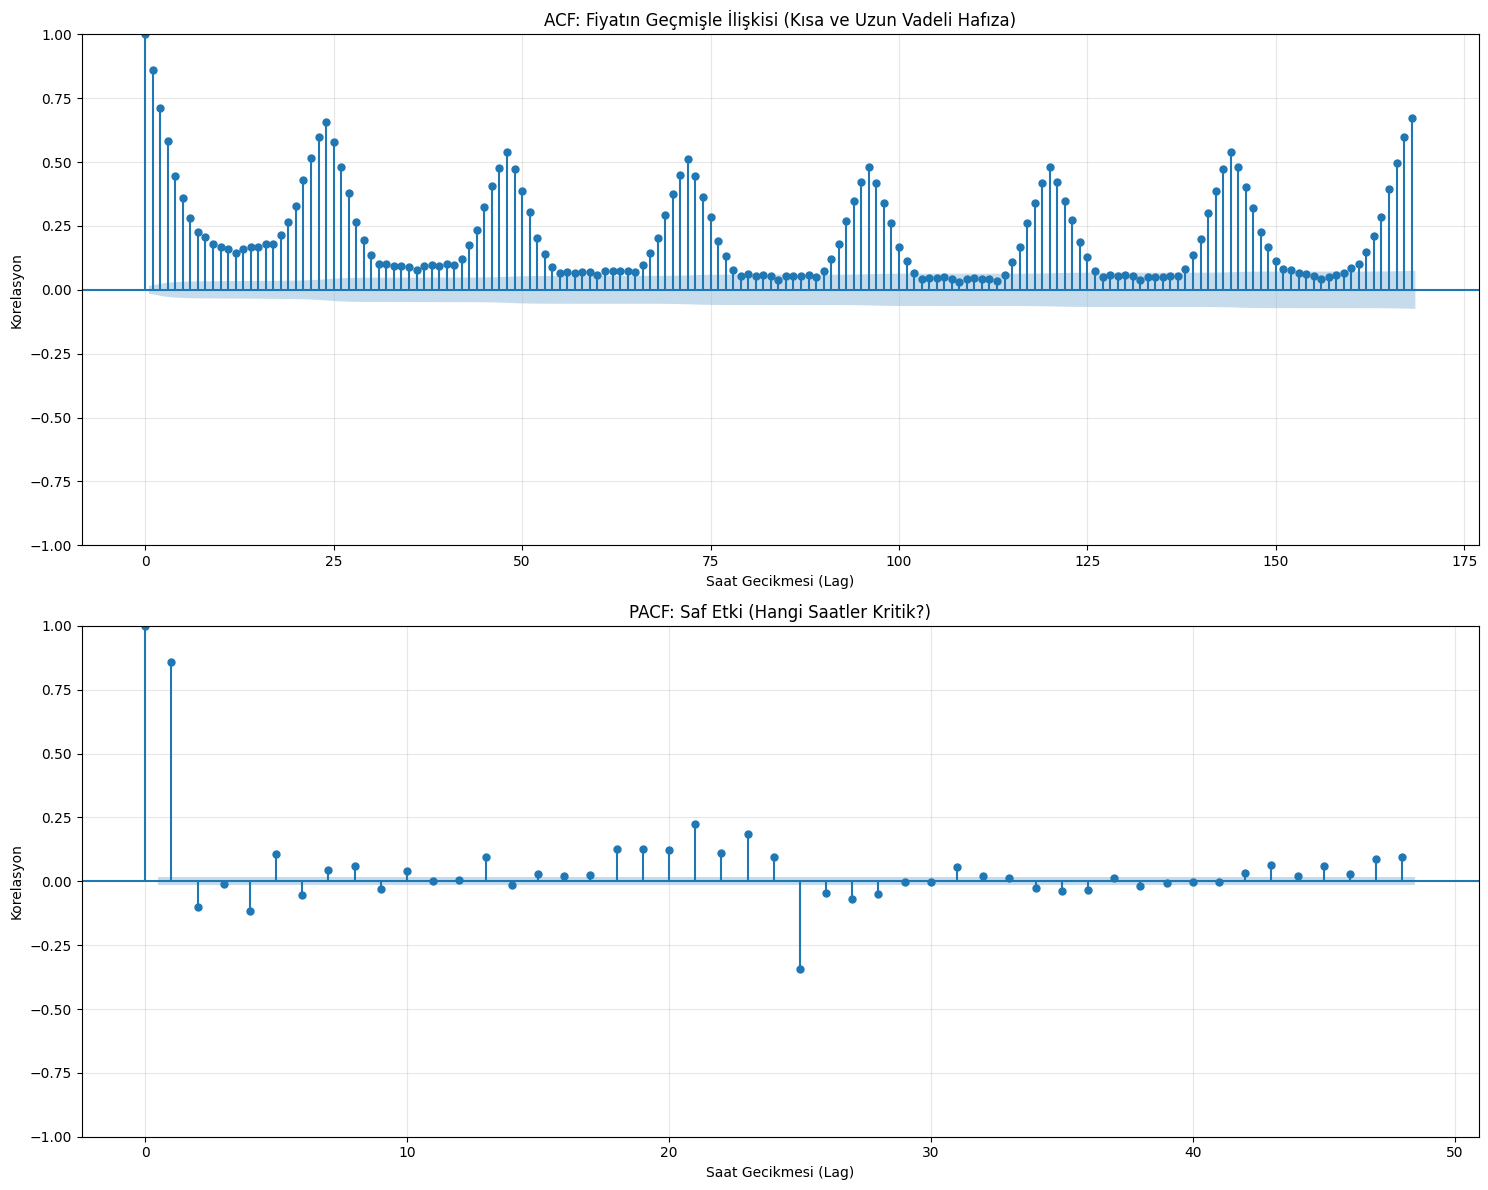

In [9]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import matplotlib.pyplot as plt

# Grafik ayarları
fig, ax = plt.subplots(2, 1, figsize=(15, 12))

# 1. ACF (AutoCorrelation Function) - Hafıza Testi
# Fiyatın geçmişteki kopyalarıyla (Lag) olan ilişkisi.
# lags=168 (1 Hafta geriye bakıyoruz)
plot_acf(data['PTF'], lags=168, ax=ax[0], title="ACF: Fiyatın Geçmişle İlişkisi (Kısa ve Uzun Vadeli Hafıza)")
ax[0].set_xlabel("Saat Gecikmesi (Lag)")
ax[0].set_ylabel("Korelasyon")
ax[0].grid(True, alpha=0.3)

# 2. PACF (Partial AutoCorrelation) - Saf Etki
# Aradaki etkileri silip, "Direkt etki eden" saatleri bulur.
plot_pacf(data['PTF'], lags=48, ax=ax[1], title="PACF: Saf Etki (Hangi Saatler Kritik?)")
ax[1].set_xlabel("Saat Gecikmesi (Lag)")
ax[1].set_ylabel("Korelasyon")
ax[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

1. ACF Grafiği
Daily Seasonality yani : 
Bugün saat 14:00'teki fiyat, yarın 14:00'teki fiyatla, öbür gün 14:00'teki fiyatla neredeyse ikiz kardeş gibi.
Hafıza: Dalgalar çok yavaş sönümleniyor (azalıyor). Yani piyasa 1 hafta öncesini bile unutmuyor.
Ders: Modelin sadece "son 1 saati" bilmesi yetmez. Ona "Geçen hafta aynı gün ne oldu?" bilgisini de vermen lazım.

2. PACF Grafiği
Çubuk 1 (Lag 1) 
En uzun çubuk bu.
Anlamı: "Gelecek saati tahmin etmek istiyorsan, en önemli ipucu şu anki saattir." Fiyat bir anda 2000'den 500'e düşmez, yavaş yavaş değişir.


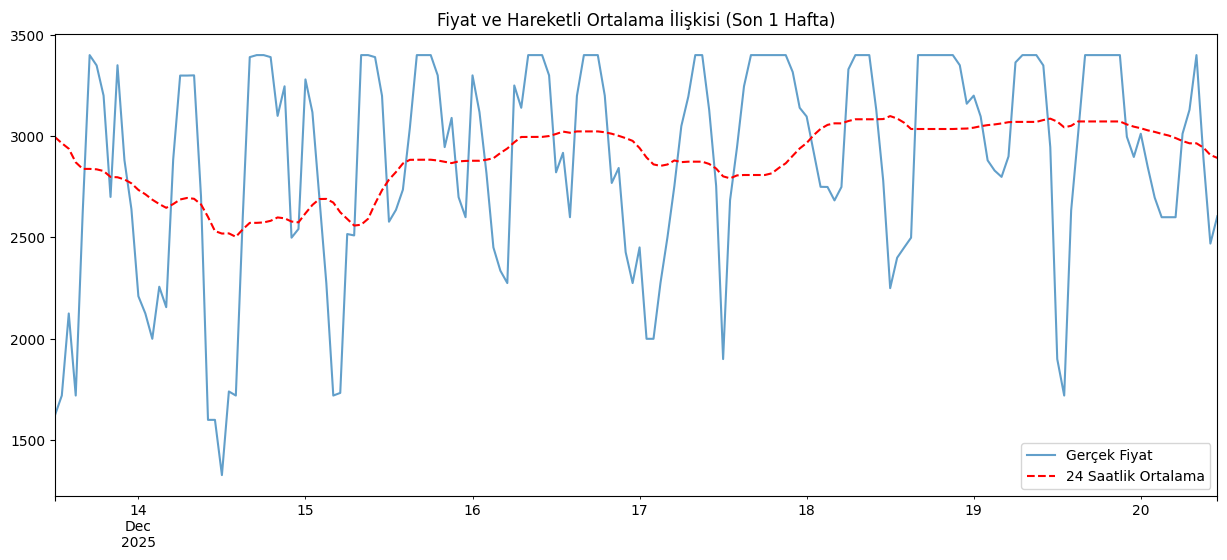

In [10]:
# --- Hareketli Ortalamalar (Trendi Yakalar) ---
# Son 24 saatin ortalaması
data['Rolling_Mean_24'] = data['PTF'].rolling(window=24).mean()

# --- Hareketli Standart Sapma (Riski/Oynaklığı Yakalar) ---
# Fiyat son 24 saatte çok mu dalgalandı?
data['Rolling_Std_24'] = data['PTF'].rolling(window=24).std()
# Görselleştirme (Fiyat vs Hareketli Ortalama)
plt.figure(figsize=(15, 6))
data['PTF'].iloc[-168:].plot(label='Gerçek Fiyat', alpha=0.7) # Son 1 hafta
data['Rolling_Mean_24'].iloc[-168:].plot(label='24 Saatlik Ortalama', color='red', linestyle='--')
plt.title("Fiyat ve Hareketli Ortalama İlişkisi (Son 1 Hafta)")
plt.legend()
plt.show()

eklenmesi gereken yeni feature'lar : 

In [11]:
# Son 24 saatin ortalaması (Trend bilgisi)
data['Rolling_Mean_24'] = data['PTF'].rolling(window=24).mean()

# Son 1 haftanın ortalaması (Uzun vadeli trend)
data['Rolling_Mean_168'] =  data['PTF'].rolling(window=168).mean()

# Son 24 saatin oynaklığı (Standart Sapma - Risk bilgisi)
data['Rolling_Std_24'] = data['PTF'].rolling(window=24).std()

# Rolling işleminden dolayı ilk satırlarda yine NaN (boşluk) oluşur, silelim.
data.dropna(inplace=True)

print("✅ Volatilite ve Trend özellikleri eklendi. Tablonun son hali:")
display(data.tail())

✅ Volatilite ve Trend özellikleri eklendi. Tablonun son hali:


,Tarih,Saat,PTF,SMF,Pozitif Dengesizlik Fiyatı (TL/MWh),Negatif Dengesizlik Fiyatı (TL/MWh),SMF Yön,month,day,season,Rolling_Mean_24,Rolling_Std_24,Rolling_Mean_168
2025-12-20 07:00:00,20.12.2025,07:00,3130.00,2321.00,2251.37,3223.90,Enerji Fazlası,12,Saturday,winter,2964.726667,465.340737,2891.769107
2025-12-20 08:00:00,20.12.2025,08:00,3400.00,3400.00,3298.00,3502.00,Enerji Açığı,12,Saturday,winter,2964.726667,465.340737,2891.769107
2025-12-20 09:00:00,20.12.2025,09:00,2892.00,3400.00,2805.24,3502.00,Enerji Açığı,12,Saturday,winter,2943.560000,456.143553,2888.932976
2025-12-20 10:00:00,20.12.2025,10:00,2469.99,2321.00,2251.37,2544.09,Enerji Fazlası,12,Saturday,winter,2906.933750,457.460609,2885.319821
2025-12-20 11:00:00,20.12.2025,11:00,2604.99,2994.88,2526.84,3084.73,Enerji Açığı,12,Saturday,winter,2892.734167,461.473855,2881.313869


bayramları ve resmi tatilleri de feature olarak ekleyelim.

In [22]:
pip install holidays

   ---------------------------------------- 0.0/1.3 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.3 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.3 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.3 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.3 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.3 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.3 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.3 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.3 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.3 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.3 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.3 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.3 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.3 MB ? eta -:--:--
   -------------------------------


[notice] A new release of pip is available: 25.0 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


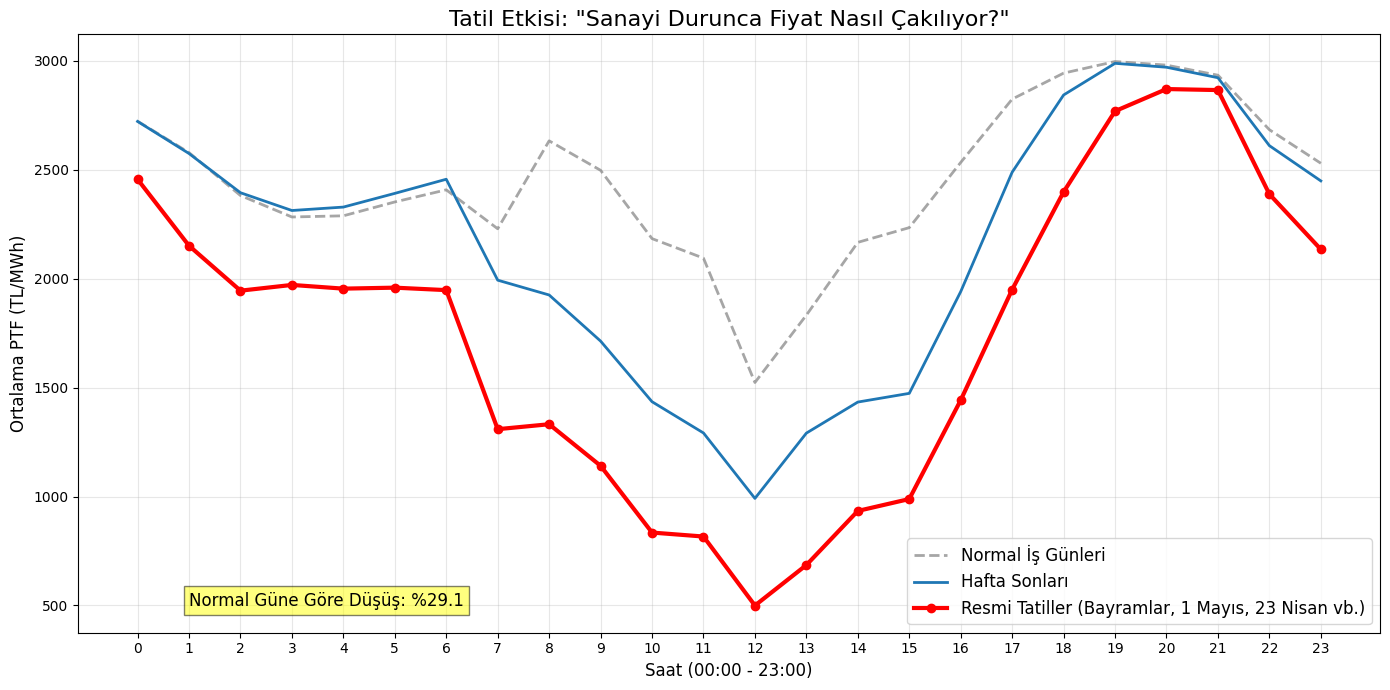

Tespit Edilen Tatil Günlerinden Örnekler:
DatetimeIndex(['2024-04-10', '2024-04-11', '2024-04-12', '2024-04-23',
               '2024-05-01', '2024-05-19', '2024-06-16', '2024-06-17',
               '2024-06-18', '2024-06-19'],
              dtype='datetime64[ns]', freq=None)


In [25]:
import holidays

# 1. Türkiye Tatillerini Çekelim (2024 ve 2025)
tr_holidays = holidays.TR(years=[2024, 2025])

# Veri setimizde 'Is_Holiday' diye bir sütun açalım
# Index'teki tarihe bakıp "Bu tarih tatil listesinde var mı?" diye soruyoruz.
# (Index'in datetime formatında olduğundan emin olalım)
data['Is_Holiday'] = data.index.map(lambda x: x.date() in tr_holidays).astype(int)

# --- ANALİZ VE GRAFİK ---

# Tatil Olan Günlerin Saatlik Ortalaması
holiday_profile = data[data['Is_Holiday'] == 1].groupby(data[data['Is_Holiday'] == 1].index.hour)['PTF'].mean()

# Normal Günlerin (Tatil Olmayan) Saatlik Ortalaması
normal_profile = data[data['Is_Holiday'] == 0].groupby(data[data['Is_Holiday'] == 0].index.hour)['PTF'].mean()

# Hafta Sonu Etkisini Görmek İstersen (Opsiyonel)
weekend_profile = data[data.index.dayofweek.isin([5, 6])].groupby(data[data.index.dayofweek.isin([5, 6])].index.hour)['PTF'].mean()

# Grafik Çizimi
plt.figure(figsize=(14, 7))

# Normal Günler
plt.plot(normal_profile.index, normal_profile.values, 
         label='Normal İş Günleri', color='gray', linestyle='--', linewidth=2, alpha=0.7)

# Hafta Sonları (Mavi)
plt.plot(weekend_profile.index, weekend_profile.values, 
         label='Hafta Sonları', color='#1f77b4', linewidth=2)

# Resmi Tatiller (Kırmızı - En Derin Düşüş Beklenir)
plt.plot(holiday_profile.index, holiday_profile.values, 
         label='Resmi Tatiller (Bayramlar, 1 Mayıs, 23 Nisan vb.)', color='red', linewidth=3, marker='o')

plt.title('Tatil Etkisi: "Sanayi Durunca Fiyat Nasıl Çakılıyor?"', fontsize=16)
plt.xlabel('Saat (00:00 - 23:00)', fontsize=12)
plt.ylabel('Ortalama PTF (TL/MWh)', fontsize=12)
plt.xticks(range(0, 24))
plt.grid(True, alpha=0.3)
plt.legend(fontsize=12)

# İstatistiksel Farkı Yazdır
diff_percent = (1 - holiday_profile.mean() / normal_profile.mean()) * 100
plt.text(1, holiday_profile.min(), 
         f"Normal Güne Göre Düşüş: %{diff_percent:.1f}", 
         fontsize=12, bbox=dict(facecolor='yellow', alpha=0.5))

plt.tight_layout()
plt.show()

# Hangi günlerin tatil olduğunu görmek istersen:
print("Tespit Edilen Tatil Günlerinden Örnekler:")
print(data[data['Is_Holiday'] == 1].index.normalize().unique()[:10])

Resmi tatillerde %30 düşüş olduguna ulastık o zaman yeni bir column ekleyelim : Is_Holiday. Ve bakalım.

In [29]:
data[data["Is_Holiday"] == 1]

,Tarih,Saat,PTF,SMF,Pozitif Dengesizlik Fiyatı (TL/MWh),Negatif Dengesizlik Fiyatı (TL/MWh),SMF Yön,month,day,season,Rolling_Mean_24,Rolling_Std_24,Rolling_Mean_168,Is_Holiday
2024-04-10 00:00:00,10.04.2024,00:00,2000.00,2238.46,1940.00,2305.61,Enerji Açığı,4,Wednesday,spring,1128.328750,859.479187,1697.804405,1
2024-04-10 01:00:00,10.04.2024,01:00,2100.00,700.00,679.00,2163.00,Enerji Fazlası,4,Wednesday,spring,1120.883333,849.800142,1696.018690,1
2024-04-10 02:00:00,10.04.2024,02:00,1999.99,675.00,654.75,2059.99,Enerji Fazlası,4,Wednesday,spring,1143.966667,866.377578,1696.209167,1
2024-04-10 03:00:00,10.04.2024,03:00,1650.01,500.00,485.00,1699.51,Enerji Fazlası,4,Wednesday,spring,1152.467500,870.461145,1694.125893,1
2024-04-10 04:00:00,10.04.2024,04:00,1445.99,450.00,436.50,1489.37,Enerji Fazlası,4,Wednesday,spring,1139.800833,863.572749,1688.751488,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-10-29 19:00:00,29.10.2025,19:00,3400.00,3400.00,3298.00,3502.00,Enerji Açığı,10,Wednesday,autumn,2550.668750,966.058586,2610.203571,1
2025-10-29 20:00:00,29.10.2025,20:00,3400.00,3400.00,3298.00,3502.00,Enerji Açığı,10,Wednesday,autumn,2550.668750,966.058586,2610.203571,1
2025-10-29 21:00:00,29.10.2025,21:00,3400.00,3400.00,3298.00,3502.00,Enerji Açığı,10,Wednesday,autumn,2550.668750,966.058586,2610.203571,1
2025-10-29 22:00:00,29.10.2025,22:00,2950.01,2950.01,2861.51,3038.51,Dengede,10,Wednesday,autumn,2544.419167,962.830127,2609.565714,1


In [31]:
data.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 17125 entries, 2024-01-07 23:00:00 to 2025-12-20 11:00:00
Data columns (total 14 columns):
 #   Column                               Non-Null Count  Dtype  
---  ------                               --------------  -----  
 0   Tarih                                17125 non-null  object 
 1   Saat                                 17125 non-null  object 
 2   PTF                                  17125 non-null  float64
 3   SMF                                  17125 non-null  float64
 4   Pozitif Dengesizlik Fiyatı (TL/MWh)  17125 non-null  float64
 5   Negatif Dengesizlik Fiyatı (TL/MWh)  17125 non-null  float64
 6   SMF Yön                              17125 non-null  object 
 7   month                                17125 non-null  int32  
 8   day                                  17125 non-null  object 
 9   season                               17125 non-null  object 
 10  Rolling_Mean_24                      17125 non-null  float6

In [32]:
data["Is_Weekend"] = data.index.dayofweek.isin([5, 6]).astype(int)

In [35]:
data[data["Tarih"] == '20.12.2025']

,Tarih,Saat,PTF,SMF,Pozitif Dengesizlik Fiyatı (TL/MWh),Negatif Dengesizlik Fiyatı (TL/MWh),SMF Yön,month,day,season,Rolling_Mean_24,Rolling_Std_24,Rolling_Mean_168,Is_Holiday,Is_Weekend
2025-12-20 00:00:00,20.12.2025,00:00,3012.01,2321.00,2251.37,3102.37,Enerji Fazlası,12,Saturday,winter,3039.075833,454.770847,2888.706369,0,1
2025-12-20 01:00:00,20.12.2025,01:00,2847.78,3400.00,2762.35,3502.00,Enerji Açığı,12,Saturday,winter,3028.691250,456.233617,2889.944524,0,1
2025-12-20 02:00:00,20.12.2025,02:00,2696.78,3275.00,2615.88,3373.25,Enerji Açığı,12,Saturday,winter,3021.030417,460.352747,2890.276548,0,1
2025-12-20 03:00:00,20.12.2025,03:00,2600.00,2600.00,2522.00,2678.00,Enerji Açığı,12,Saturday,winter,3011.433333,466.856111,2889.222976,0,1
2025-12-20 04:00:00,20.12.2025,04:00,2599.98,2599.98,2521.98,2677.98,Dengede,12,Saturday,winter,3003.140417,472.526792,2889.222917,0,1
2025-12-20 05:00:00,20.12.2025,05:00,2599.99,2401.00,2328.97,2677.99,Enerji Fazlası,12,Saturday,winter,2990.640000,479.293781,2890.164643,0,1
2025-12-20 06:00:00,20.12.2025,06:00,3012.00,3012.00,2921.64,3102.36,Enerji Açığı,12,Saturday,winter,2975.976667,472.715381,2891.692083,0,1
2025-12-20 07:00:00,20.12.2025,07:00,3130.00,2321.00,2251.37,3223.90,Enerji Fazlası,12,Saturday,winter,2964.726667,465.340737,2891.769107,0,1
2025-12-20 08:00:00,20.12.2025,08:00,3400.00,3400.00,3298.00,3502.00,Enerji Açığı,12,Saturday,winter,2964.726667,465.340737,2891.769107,0,1
2025-12-20 09:00:00,20.12.2025,09:00,2892.00,3400.00,2805.24,3502.00,Enerji Açığı,12,Saturday,winter,2943.560000,456.143553,2888.932976,0,1


In [36]:
data.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 17125 entries, 2024-01-07 23:00:00 to 2025-12-20 11:00:00
Data columns (total 15 columns):
 #   Column                               Non-Null Count  Dtype  
---  ------                               --------------  -----  
 0   Tarih                                17125 non-null  object 
 1   Saat                                 17125 non-null  object 
 2   PTF                                  17125 non-null  float64
 3   SMF                                  17125 non-null  float64
 4   Pozitif Dengesizlik Fiyatı (TL/MWh)  17125 non-null  float64
 5   Negatif Dengesizlik Fiyatı (TL/MWh)  17125 non-null  float64
 6   SMF Yön                              17125 non-null  object 
 7   month                                17125 non-null  int32  
 8   day                                  17125 non-null  object 
 9   season                               17125 non-null  object 
 10  Rolling_Mean_24                      17125 non-null  float6

In [41]:
categorical_cols = ["Is_Weekend", "Is_Holiday","month","day","season"]

for col in categorical_cols:
    if col in data.columns:
        if data[col].dtype.name == 'category':
            continue
        else:
            data[col] = data[col].astype('category')

In [42]:
data.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 17125 entries, 2024-01-07 23:00:00 to 2025-12-20 11:00:00
Data columns (total 15 columns):
 #   Column                               Non-Null Count  Dtype   
---  ------                               --------------  -----   
 0   Tarih                                17125 non-null  object  
 1   Saat                                 17125 non-null  object  
 2   PTF                                  17125 non-null  float64 
 3   SMF                                  17125 non-null  float64 
 4   Pozitif Dengesizlik Fiyatı (TL/MWh)  17125 non-null  float64 
 5   Negatif Dengesizlik Fiyatı (TL/MWh)  17125 non-null  float64 
 6   SMF Yön                              17125 non-null  object  
 7   month                                17125 non-null  category
 8   day                                  17125 non-null  category
 9   season                               17125 non-null  category
 10  Rolling_Mean_24                      17125 non-

In [44]:
# Lag 1: Bir saat önceki fiyat (En önemli anlık gösterge)
data['Lag_1'] = data['PTF'].shift(1)

# Lag 24: Dün aynı saatteki fiyat (Günlük döngü)
data['Lag_24'] = data['PTF'].shift(24)

# Lag 168: Geçen hafta aynı saatteki fiyat (Haftalık döngü - Örn: Geçen Salı)
data['Lag_168'] = data['PTF'].shift(168)

In [47]:
data.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 17125 entries, 2024-01-07 23:00:00 to 2025-12-20 11:00:00
Data columns (total 18 columns):
 #   Column                               Non-Null Count  Dtype   
---  ------                               --------------  -----   
 0   Tarih                                17125 non-null  object  
 1   Saat                                 17125 non-null  object  
 2   PTF                                  17125 non-null  float64 
 3   SMF                                  17125 non-null  float64 
 4   Pozitif Dengesizlik Fiyatı (TL/MWh)  17125 non-null  float64 
 5   Negatif Dengesizlik Fiyatı (TL/MWh)  17125 non-null  float64 
 6   SMF Yön                              17125 non-null  object  
 7   month                                17125 non-null  category
 8   day                                  17125 non-null  category
 9   season                               17125 non-null  category
 10  Rolling_Mean_24                      17125 non-

In [50]:
# Temizlikten önceki durum
print(f"🧹 Temizlik Öncesi Satır Sayısı: {len(data)}")

# İçinde 1 tane bile NaN (Boşluk) olan satırı komple sil
data.dropna(inplace=True)

# Temizlik sonrası durum
print(f"✨ Temizlik Sonrası Satır Sayısı: {len(data)}")

# KONTROL: Hiç NaN kaldı mı?
bosluk_var_mi = data.isnull().sum().sum()
if bosluk_var_mi == 0:
    print("✅ MÜKEMMEL! Veri seti artık %100 dolu ve saf.")
else:
    print(f"⚠️ DİKKAT: Hala {bosluk_var_mi} adet boşluk var!")

🧹 Temizlik Öncesi Satır Sayısı: 17125
✨ Temizlik Sonrası Satır Sayısı: 16957
✅ MÜKEMMEL! Veri seti artık %100 dolu ve saf.


In [51]:
data.to_pickle("../data/processed/epias_feature_engineered.pkl")